# 01 - Gradient Descent

**Section:** Foundations | **Prereqs:** `Math.ipynb` | **Next:** `ANNs/ANNs.ipynb`

Training a network is one idea repeated a few million times: *move each
parameter a small step downhill on the loss surface.* This notebook implements
that by hand, in 1D and 2D, before PyTorch's autograd hides it.

**The update rule**

    x <- x - learning_rate * f'(x)

The derivative points uphill, so subtracting it walks downhill. The learning
rate sets the step size and is the single most consequential hyperparameter in
deep learning.

**What you learn here**
- Descent on a convex parabola, where it always works.
- The two ways it fails: getting stuck at a *stationary point* (derivative = 0)
  and settling in a *local* minimum instead of the global one.
- Why the starting point matters, and why 2D surfaces have saddle points.
- Adaptive learning rates (gradient-scaled and time-based) - the seed of the
  optimizers (RMSprop, Adam) covered in `Metaparameters/`.

In [1]:
# Imports. %matplotlib inline renders plots in the notebook output.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import math
import scipy
%matplotlib inline

## 1) Gradient Decent in 1D

In [2]:
# A convex parabola and its analytic derivative.
# f(x) = 3x^2 - 3x + 4  ->  f'(x) = 6x - 3, zero at x = 0.5 (the true minimum).
# Here the derivative is hand-derived; PyTorch's autograd will do this for us later.
def f(x):
  return 3*x**2 - 3*x + 4

def deriv(x):
   return 6*x -3

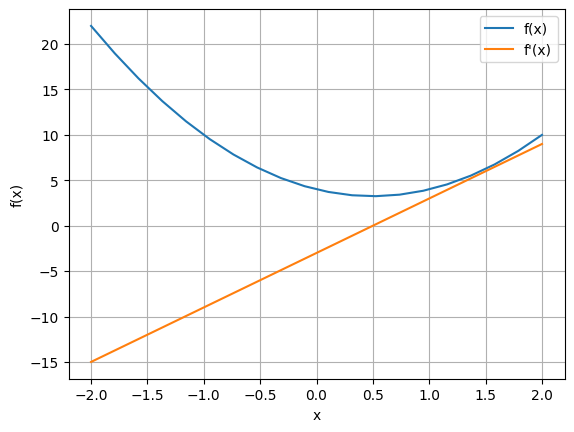

In [3]:
# Plot function and derivative together. Two things to read off the graph:
# the derivative crosses zero exactly at the minimum, and its SIGN tells you
# which way is downhill on either side.
x = np.linspace(-2,2,20)

fig, ax = plt.subplots()
ax.plot(x,f(x))
ax.plot(x,deriv(x))
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(['f(x)','f\'(x)']);
ax.grid()

In [4]:
# The function values themselves - a sanity check on the shape.
print(f(x))

[22.         18.97506925 16.21606648 13.72299169 11.49584488  9.53462604
  7.83933518  6.4099723   5.2465374   4.34903047  3.71745152  3.35180055
  3.25207756  3.41828255  3.85041551  4.54847645  5.51246537  6.74238227
  8.23822715 10.        ]


In [5]:
# Gradient descent, the whole algorithm in four lines:
# start somewhere random, then repeatedly step against the gradient.
# 200 steps at lr=0.01 lands close to the analytic minimum x = 0.5.
## Computing Gradient Decent

localmin = np.random.choice(x,1)
print(localmin)

learning_rate = 0.01
epochs = 200

for i in range(epochs):
  grad = deriv(localmin)
  localmin = localmin - learning_rate*grad

print(localmin)

[0.94736842]
[0.50000189]


In [6]:
# Same descent, but logging the position and gradient at every step so we can
# watch the trajectory. Smaller lr (0.001) needs more epochs to cover the ground.
## Graphing the decent

localmin = np.random.choice(x,1)
print(localmin)

learning_rate = 0.001
epochs = 1000

modelparams = np.zeros((epochs,2))

for i in range(epochs):
  grad = deriv(localmin)
  localmin = localmin - learning_rate*grad
  modelparams[i,0] = localmin[0]
  modelparams[i,1] = grad[0]




[-1.15789474]


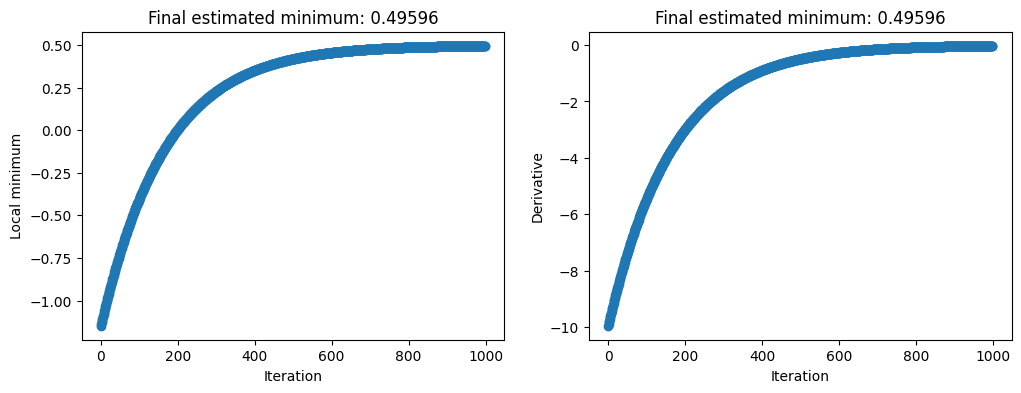

In [7]:
# The two diagnostic curves of any training run:
# left  - the parameter converging to its final value,
# right - the gradient decaying towards zero as we approach the minimum.
# A gradient that never flattens means the learning rate is too large.

fig,ax = plt.subplots(1,2,figsize=(12,4))

for i in range(2):
  ax[i].plot(modelparams[:,i],'o-')
  ax[i].set_xlabel('Iteration')
  ax[i].set_title(f'Final estimated minimum: {localmin[0]:.5f}')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')

plt.show()

## Code Challenge

In [8]:
# A non-convex function: cos(2*pi*x) + x^2. Many local minima, one global
# minimum at x = 0 ... which is also where the derivative is exactly zero.
def f(x):
  return np.cos(2*math.pi*x) + x**2

def deriv(x):
   return (-np.sin(2*math.pi*x)*2*math.pi) + 2*x



In [9]:
# The failure case. Starting at x = 0 the gradient is exactly 0, so the update
# is 0 and descent never moves - a stationary point traps it.
# Try localmin = 0.5 or a random start: it then falls into whichever local
# minimum is nearest. Where you start decides where you end up.
## Gradient Decent for this

x = np.linspace(-2,2,2000)

learning_rate = 0.001
epochs = 1000

localmin = 0


for i in range(epochs):
  grad = deriv(localmin)
  localmin = localmin - learning_rate*grad

print(localmin)


## Gradient descent fails here: we START at x = 0, where the derivative is
## exactly zero, so every update is zero and the algorithm never moves.
## That is a stationary point (here a local MAXIMUM), not vanishing gradients -
## vanishing gradients is a different problem, about gradients shrinking as they
## are propagated back through many layers. Start from another x and it converges
## to whichever local minimum happens to be nearest.

0.0


## Gradient decent in 2D

### Gradient of a Scalar Function

If $f : \mathbb{R}^n \to \mathbb{R}$, then the **gradient** of $f$ is:

$$
\nabla f(\mathbf{x}) = \begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}
$$


Remember: Nabla (triangle) is a vector of all partial derivaties at that point.. So a 2D function will have 2 elements in the vector.

In [10]:
# The classic 'peaks' surface - a 2D landscape with several peaks, valleys and
# saddle points. Real loss surfaces look like this in millions of dimensions.
def peaks(x, y):
    x ,y = np.meshgrid(x, y)
    term1 = 3 * (1 + x)**2 * np.exp(-x**2 - (y - 1)**2)
    term2 = 10 * (x / 5 - x**3 - y**5) * np.exp(-(x + 1)**2 - y**2)
    return term1 - term2




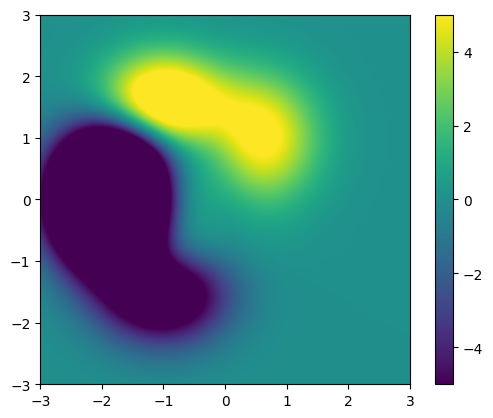

In [11]:
# Visualising the surface. The gradient here is a VECTOR (one partial derivative
# per axis); descent follows the steepest direction, not just left/right.
X = np.linspace(-3,3,1000)
Y = np.linspace(-3,3,1000)

Z = peaks(X,Y)

plt.imshow(Z, extent=[X[0],X[-1],Y[0], Y[-1]], origin='lower', vmin=-5, vmax = 5)
plt.colorbar();


## Dynamic Learning Rate

In [12]:
# Two runs from the same start, compared:
#   ModelParamsGrad - learning rate scaled by |gradient| (big steps when far
#                     from the minimum, tiny steps once close),
#   modelparams     - a fixed learning rate.
# This is the idea behind adaptive optimizers such as RMSprop and Adam.
# Gradient Based Learing Rate

def f(x):
  return 3*x**2 - 3*x + 4

def deriv(x):
   return 6*x -3

x = np.linspace(-2,2,200)
localmin = 0.64
learning_rate = 0.001
epochs = 10000

ModelParamsGrad = np.zeros((epochs,3))

for i in range(epochs):
  grad = deriv(localmin)

  lr = learning_rate * np.abs(grad)

  localmin = localmin - (lr *grad)

  ModelParamsGrad[i,0] = localmin
  ModelParamsGrad[i,1] = grad
  ModelParamsGrad[i,2] = lr


x = np.linspace(-2,2,200)
localmin = 0.64
learning_rate = 0.001
epochs = 10000

modelparams = np.zeros((epochs,3))

for i in range(epochs):

  grad = deriv(localmin)
  localmin = localmin - grad*learning_rate

  modelparams[i,0] = localmin
  modelparams[i,1] = grad
  modelparams[i,2] = learning_rate

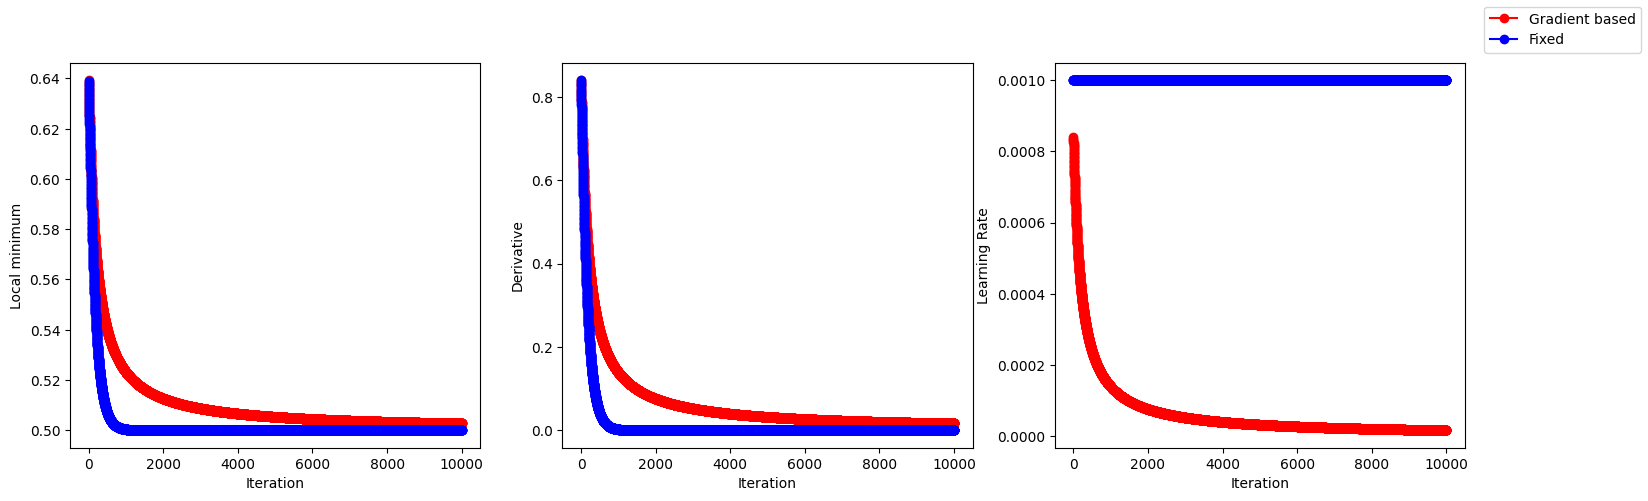

In [13]:
# Red = gradient-scaled lr, blue = fixed lr. The gradient-scaled run converges
# faster at first, then slows down automatically as the gradient shrinks -
# see the third panel, where its learning rate decays on its own.

fig,ax = plt.subplots(1,3, figsize=(18,5))
for i in range(3):
  ax[i].plot(ModelParamsGrad[:,i], "-o",color='red')
  ax[i].plot(modelparams[:,i], "-o",color='blue')

  ax[i].set_xlabel('Iteration')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')
ax[2].set_ylabel('Learning Rate')
fig.legend(["Gradient based", "Fixed"])



plt.show()



In [14]:
# The other common schedule: time-based decay, lr shrinking with the epoch
# count. Implemented for real in Metaparameters/LearningRateDecay.ipynb.
# lr = learning_rate * (1- (i+1)/ephoch)

# This is time based learing rate